# Iris Flower Classification — End-to-End ML Pipeline

**DevRise Internship Program — Batch 1 (2026) | Domain: AI & ML | Task 2**

This notebook implements a complete, end-to-end supervised machine learning
classification pipeline on the classic **Iris dataset**, covering:

1. Data Loading & Cleaning
2. Exploratory Data Analysis (distributions, pair grids, correlation)
3. Preprocessing (scaling, train/test split with stratification to avoid data leakage)
4. Model Training — Logistic Regression, Decision Tree, Random Forest
5. Model Evaluation — Accuracy, Precision, Recall, F1-Score, Confusion Matrix
6. Comparative Model Analysis
7. Decision Boundary Visualization
8. Final Model Selection & Export


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Directory to save exported plots (matches deliverable requirements)
PLOTS_DIR = "../outputs/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load & Clean the Dataset

We use `sklearn.datasets.load_iris`, the canonical version of the Iris dataset
(150 samples, 4 numeric features, 3 balanced classes). We convert it into a
pandas DataFrame for cleaning, profiling, and exploratory analysis.

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# --- Data cleaning & profiling ---
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

# Drop exact duplicate rows if any (keeps pipeline robust/reproducible)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nRows before: {before}, after de-duplication: {len(df)}")


Missing values per column:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Duplicate rows: 1

Data types:
 sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Rows before: 150, after de-duplication: 149


In [4]:
# Statistical profile of numeric features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),149.0,5.843624,0.830851,4.3,5.1,5.8,6.4,7.9
sepal width (cm),149.0,3.059732,0.436342,2.0,2.8,3.0,3.3,4.4
petal length (cm),149.0,3.748993,1.767791,1.0,1.6,4.3,5.1,6.9
petal width (cm),149.0,1.194631,0.762622,0.1,0.3,1.3,1.8,2.5


In [5]:
# Class balance check
df["species"].value_counts()


species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

## 3. Exploratory Data Analysis

Feature distributions and pairwise relationships help us understand class
separability before modeling.

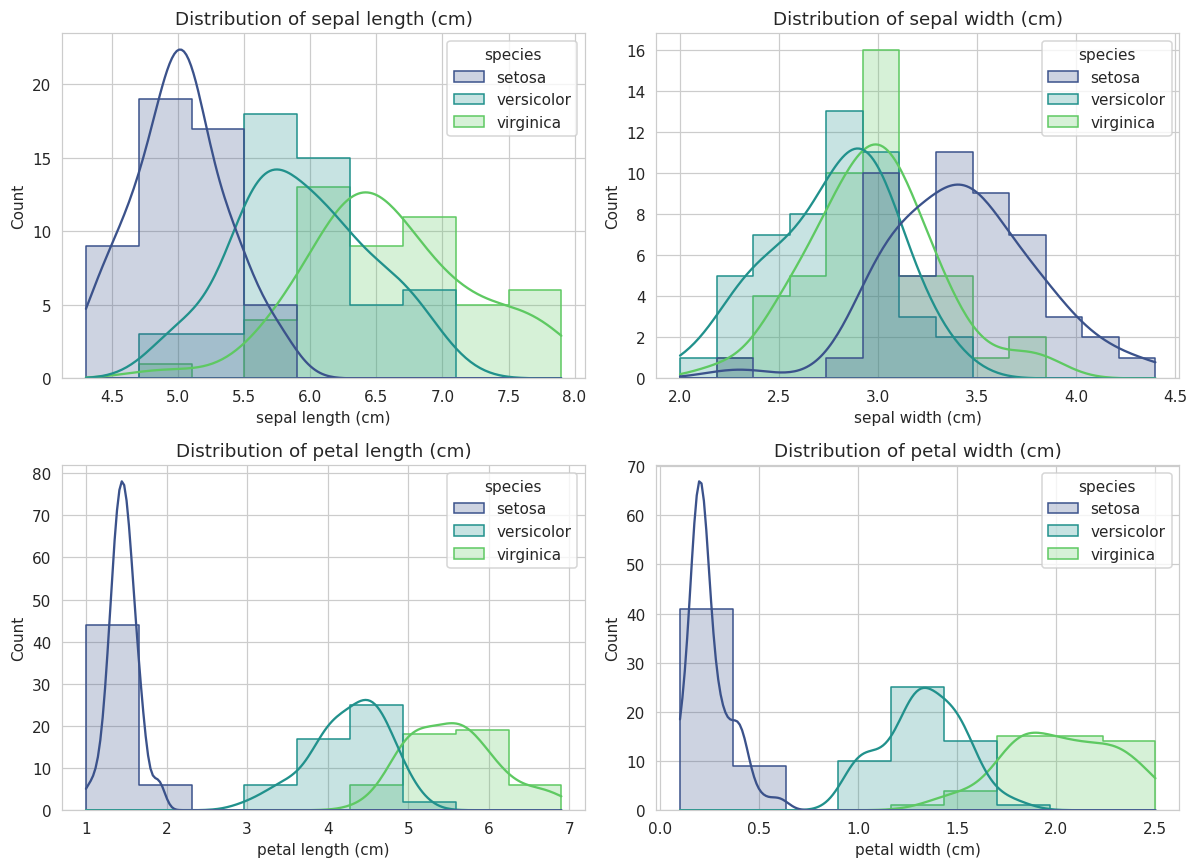

In [6]:
# --- Feature distribution plots ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for ax, col in zip(axes, iris.feature_names):
    sns.histplot(data=df, x=col, hue="species", kde=True, ax=ax, palette="viridis", element="step")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/feature_distributions.png", bbox_inches="tight")
plt.show()


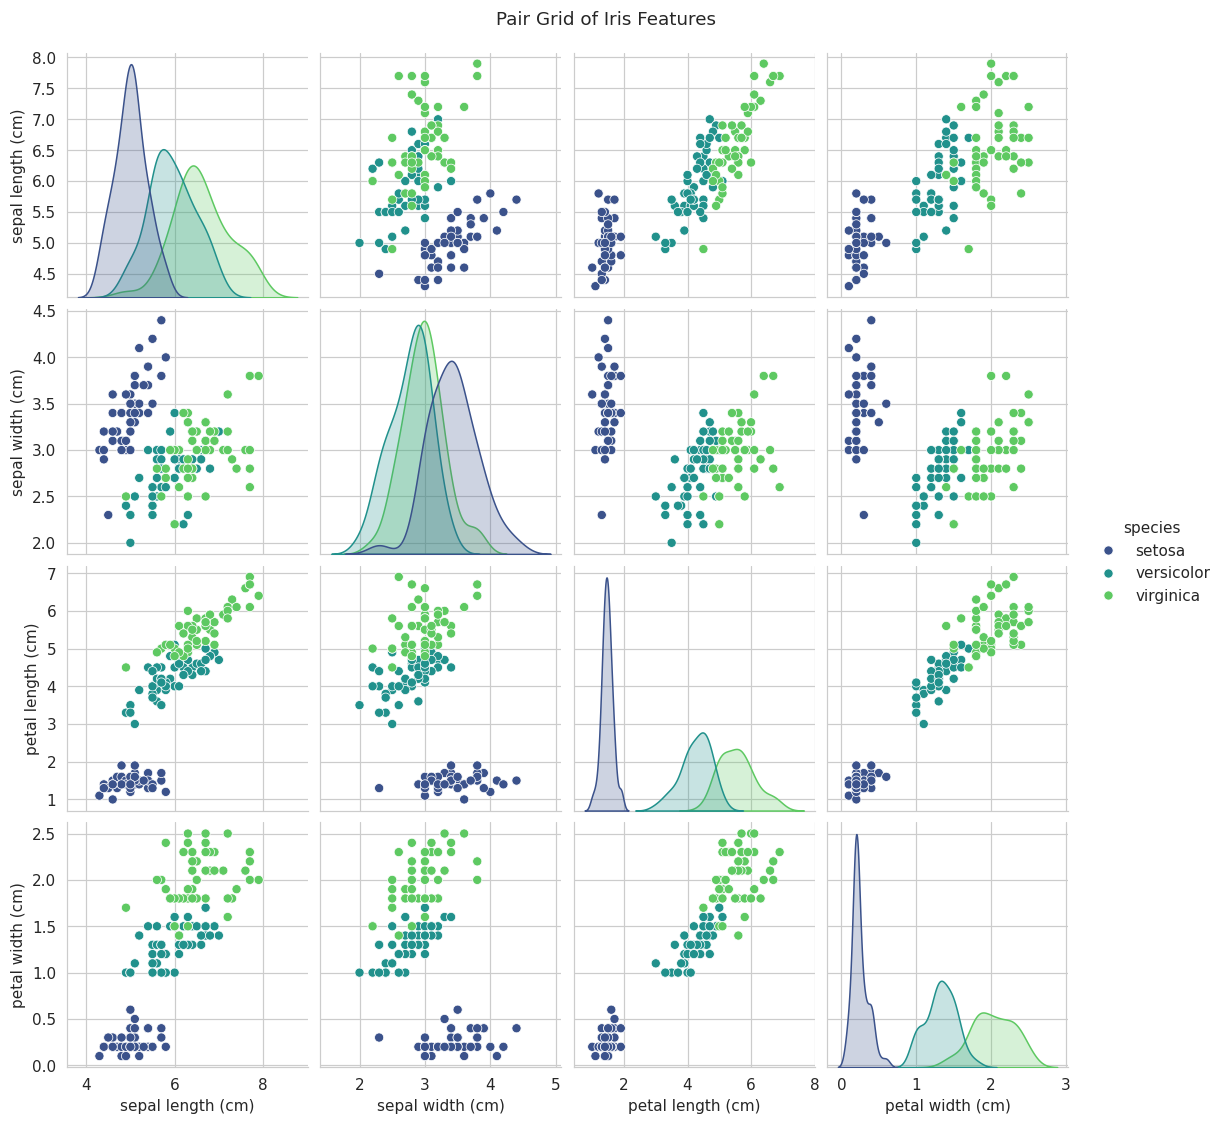

In [7]:
# --- Pair grid (pairplot) ---
pair_plot = sns.pairplot(df, hue="species", palette="viridis", diag_kind="kde", corner=False)
pair_plot.fig.suptitle("Pair Grid of Iris Features", y=1.02)
pair_plot.savefig(f"{PLOTS_DIR}/pairplot.png", bbox_inches="tight")
plt.show()


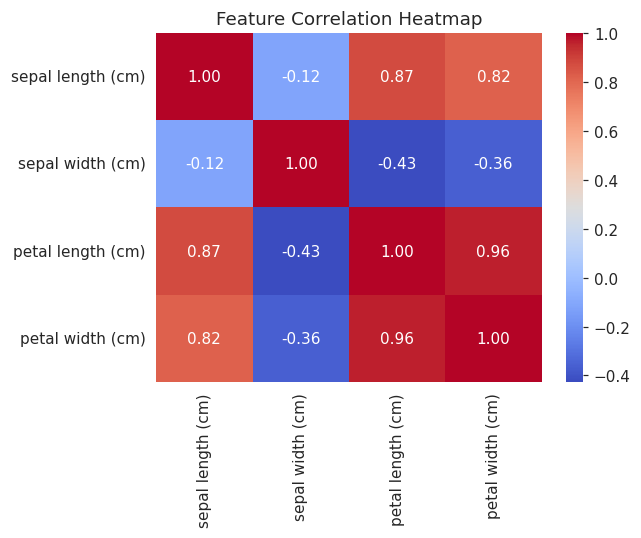

In [8]:
# --- Correlation heatmap ---
plt.figure(figsize=(6, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/correlation_heatmap.png", bbox_inches="tight")
plt.show()


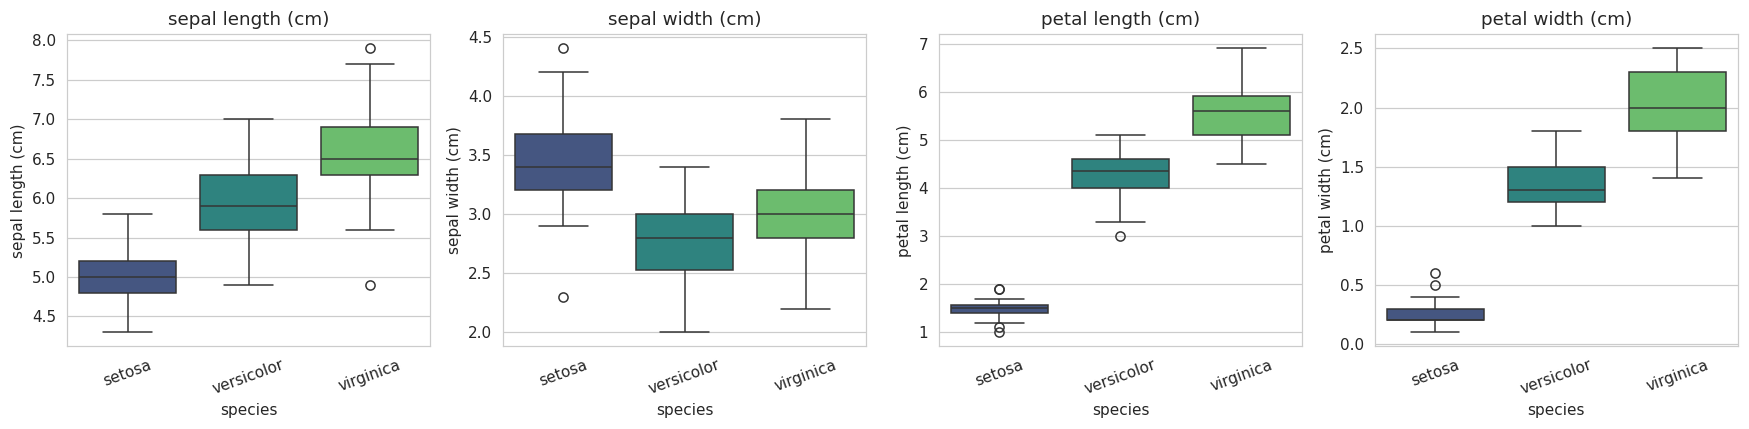

In [9]:
# --- Boxplots to inspect outliers per feature ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, iris.feature_names):
    sns.boxplot(data=df, x="species", y=col, ax=ax, palette="viridis")
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/boxplots_outliers.png", bbox_inches="tight")
plt.show()


## 4. Preprocessing: Features, Encoding, Scaling, Train/Test Split

To avoid **data leakage**, we:
- Split the data into training and test sets **before** fitting the scaler.
- Fit `StandardScaler` only on the training set, then transform both sets.
- Use **stratified** splitting to preserve class balance in both sets.

In [10]:
X = df[iris.feature_names].values
y = df["species"].cat.codes.values  # numeric target (0,1,2)
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))

# Fit scaler ONLY on training data, then transform both -> prevents leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nScaling complete. Training mean ~0, std ~1:")
print(np.round(X_train_scaled.mean(axis=0), 2), np.round(X_train_scaled.std(axis=0), 2))


Train shape: (119, 4)  Test shape: (30, 4)
Train class distribution: [40 40 39]
Test class distribution: [10 10 10]

Scaling complete. Training mean ~0, std ~1:
[-0.  0.  0.  0.] [1. 1. 1. 1.]


## 5. Model Training

We train and compare three classifiers, as suggested in the task requirements:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")


Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [12]:
# 5-fold cross validation on training data (extra robustness check)
cv_results = {}
for name, model in trained_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name}: CV Accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression: CV Accuracy = 0.9583 (+/- 0.0264)


Decision Tree: CV Accuracy = 0.9500 (+/- 0.0408)


Random Forest: CV Accuracy = 0.9500 (+/- 0.0312)


## 6. Model Evaluation on Test Set

For each model we compute **Accuracy, Precision, Recall, F1-Score** (macro-averaged,
appropriate for balanced multi-class problems) and plot a **Confusion Matrix heatmap**.

In [13]:
results = []
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.966667,0.969697,0.966667,0.966583
1,Logistic Regression,0.933333,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333,0.933333


In [14]:
# --- Detailed classification report per model ---
for name, y_pred in predictions.items():
    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=class_names))



=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00   

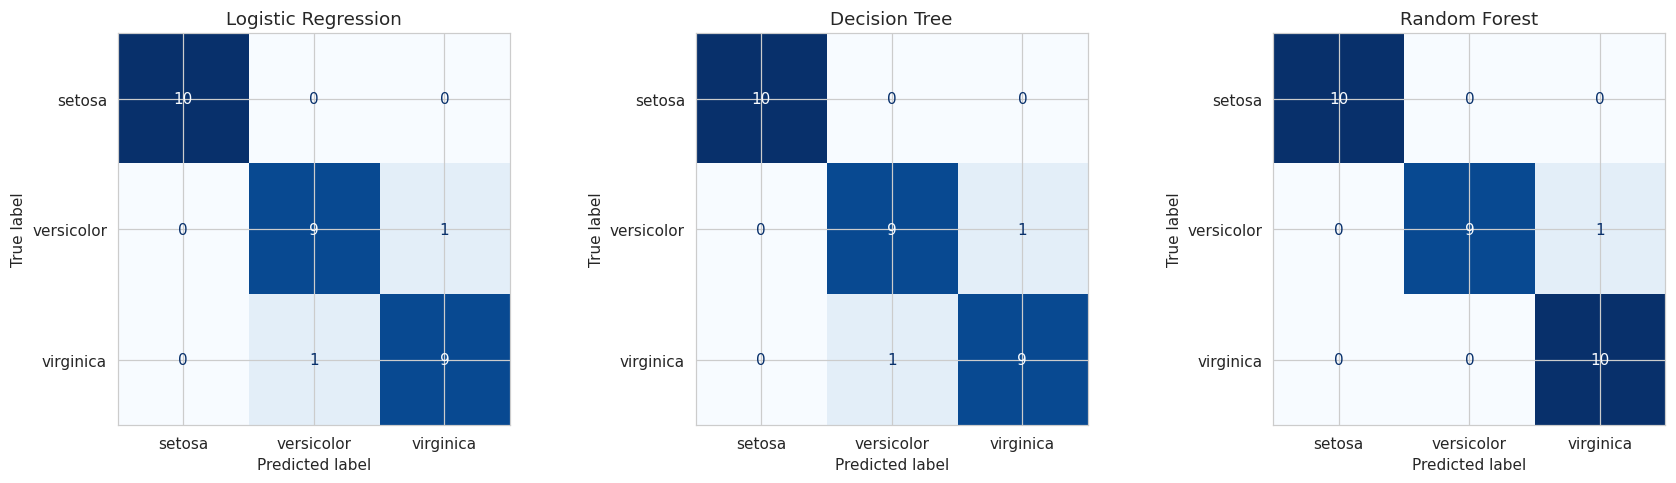

In [15]:
# --- Confusion Matrix Heatmaps (exported per requirements) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/confusion_matrix_heatmaps.png", bbox_inches="tight")
plt.show()


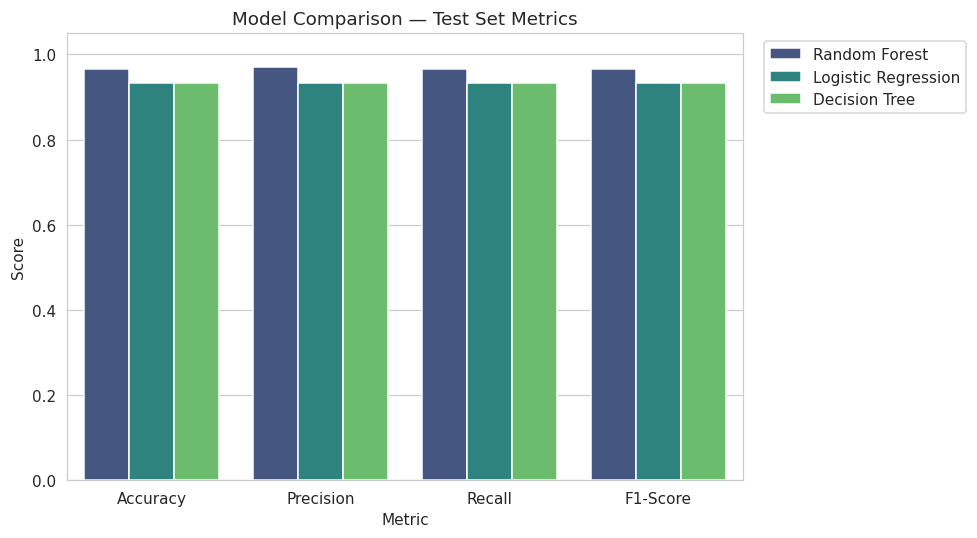

In [16]:
# --- Model comparison bar chart ---
metrics_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_melt, x="Metric", y="Score", hue="Model", palette="viridis")
plt.ylim(0, 1.05)
plt.title("Model Comparison — Test Set Metrics")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/model_comparison_metrics.png", bbox_inches="tight")
plt.show()


## 7. Decision Boundary Visualization

To visualize how each model separates classes, we retrain lightweight 2-feature
versions of each model on **petal length** and **petal width** (the two most
discriminative features from the EDA above) and plot their decision boundaries.

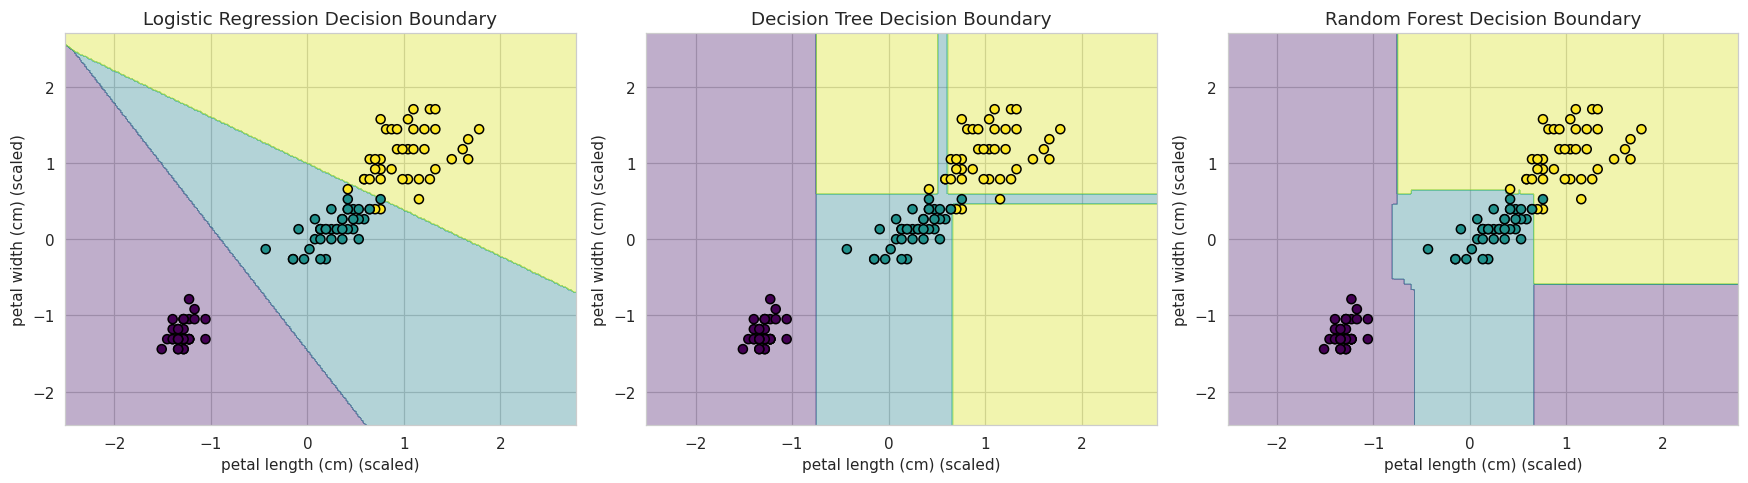

In [17]:
feat_idx = [2, 3]  # petal length, petal width
feat_names = [iris.feature_names[i] for i in feat_idx]

X2 = X[:, feat_idx]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

boundary_models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
}
for m in boundary_models.values():
    m.fit(X2_train_s, y2_train)

x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, m) in zip(axes, boundary_models.items()):
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap="viridis")
    scatter = ax.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap="viridis",
                          edgecolor="k", s=35)
    ax.set_title(f"{name} Decision Boundary")
    ax.set_xlabel(f"{feat_names[0]} (scaled)")
    ax.set_ylabel(f"{feat_names[1]} (scaled)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/decision_boundaries.png", bbox_inches="tight")
plt.show()


## 8. Feature Importance (Tree-based Models)

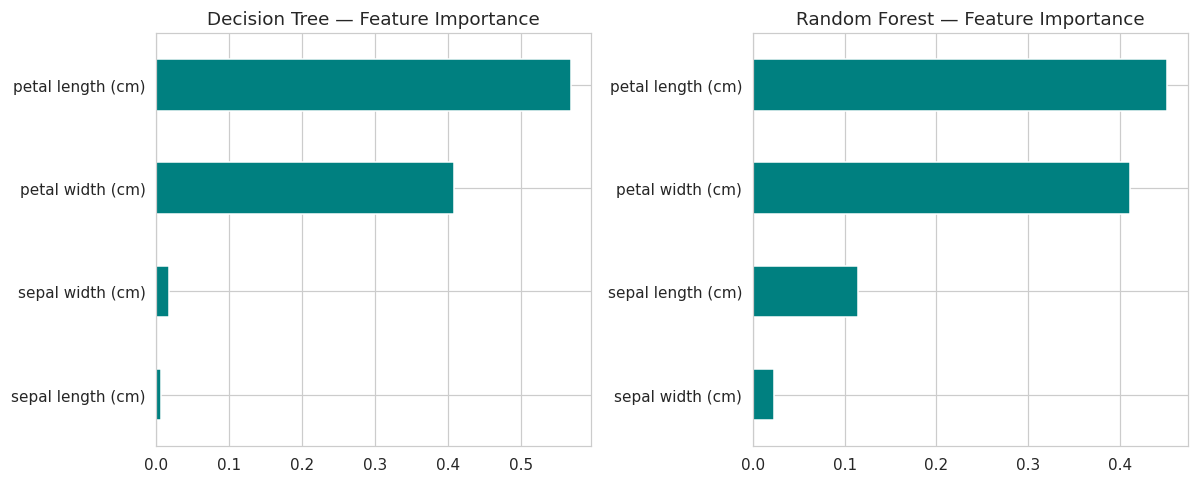

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, ["Decision Tree", "Random Forest"]):
    model = trained_models[name]
    importances = pd.Series(model.feature_importances_, index=iris.feature_names).sort_values()
    importances.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"{name} — Feature Importance")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/feature_importance.png", bbox_inches="tight")
plt.show()


## 9. Final Model Selection & Summary

Based on the comparative test-set metrics above, we select the best-performing
model and summarize the final results.

In [19]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(results_df)

final_summary = {
    "best_model": best_model_name,
    "test_accuracy": float(results_df.iloc[0]["Accuracy"]),
    "test_precision_macro": float(results_df.iloc[0]["Precision"]),
    "test_recall_macro": float(results_df.iloc[0]["Recall"]),
    "test_f1_macro": float(results_df.iloc[0]["F1-Score"]),
}
final_summary


Best performing model: Random Forest
                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.966667   0.969697  0.966667  0.966583
1  Logistic Regression  0.933333   0.933333  0.933333  0.933333
2        Decision Tree  0.933333   0.933333  0.933333  0.933333


{'best_model': 'Random Forest',
 'test_accuracy': 0.9666666666666667,
 'test_precision_macro': 0.9696969696969697,
 'test_recall_macro': 0.9666666666666667,
 'test_f1_macro': 0.9665831244778612}

In [20]:
import json
os.makedirs("../outputs/reports", exist_ok=True)

# Save full comparative metrics table
results_df.to_csv("../outputs/reports/model_comparison_results.csv", index=False)

# Save final summary
with open("../outputs/reports/final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print("Reports exported to outputs/reports/")
print("Plots exported to outputs/plots/")


Reports exported to outputs/reports/
Plots exported to outputs/plots/


## 10. Conclusion

This notebook delivered a complete, leakage-safe classification pipeline for the
Iris dataset: data cleaning, EDA (distributions, pair grids, correlation, outliers),
scaled train/test split, training and cross-validating three classifiers,
full evaluation (Accuracy / Precision / Recall / F1 / Confusion Matrix),
decision boundary visualization, and feature importance analysis — with all
plots and metric reports exported to the `outputs/` directory for submission.
